<a href="https://colab.research.google.com/github/Priyanshu16705/Code-Sync/blob/main/CNN_Lab_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Lab Assignment — Task 1

**Name:** Priyanshu Kumar  
**Roll Number:** 24IT3039

**Framework Used:** TensorFlow / Keras  

All random seeds are set to 42 to ensure reproducibility.

This notebook contains:
- Environment verification
- Dataset exploration
- Preprocessing pipeline
- Data augmentation pipeline
- Analysis answers (in full sentences)

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import os


In [2]:

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)

# GPU check
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", len(gpus) > 0)
print("GPU List:", gpus)

TensorFlow Version: 2.19.0
NumPy Version: 2.0.2
Pandas Version: 2.2.2
GPU Available: False
GPU List: []


In [3]:
#  Set seed everywhere (IMPORTANT)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

#  Explanation:
# numpy seed → controls random arrays
# tf seed → controls model weights & ops
# python random → controls python randomness
# PYTHONHASHSEED → ensures consistent hashing

In [4]:
from tensorflow.keras.datasets import mnist, cifar10

# Load datasets
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

# (a) Shapes
print("MNIST Train Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR Train Shape:", x_train_cifar.shape)
print("CIFAR Test Shape:", x_test_cifar.shape)

# (b) dtype & range
print("\nMNIST dtype:", x_train_mnist.dtype)
print("MNIST range:", x_train_mnist.min(), "to", x_train_mnist.max())

print("\nCIFAR dtype:", x_train_cifar.dtype)
print("CIFAR range:", x_train_cifar.min(), "to", x_train_cifar.max())

# (c) samples per class
unique, counts = np.unique(y_train_mnist, return_counts=True)
print("\nMNIST Class Distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)

MNIST dtype: uint8
MNIST range: 0 to 255

CIFAR dtype: uint8
CIFAR range: 0 to 255

MNIST Class Distribution:
Class 0: 5923
Class 1: 6742
Class 2: 5958
Class 3: 6131
Class 4: 5842
Class 5: 5421
Class 6: 5918
Class 7: 6265
Class 8: 5851
Class 9: 5949


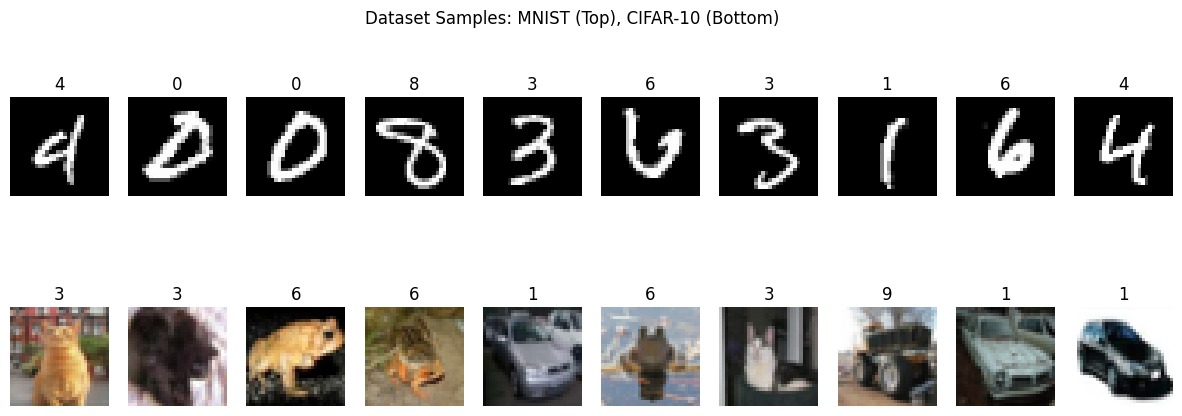

In [5]:
fig, axes = plt.subplots(2, 10, figsize=(15,5))

# MNIST
for i in range(10):
    idx = np.random.randint(0, len(x_train_mnist))
    axes[0, i].imshow(x_train_mnist[idx], cmap='gray')
    axes[0, i].set_title(y_train_mnist[idx])
    axes[0, i].axis('off')

# CIFAR
for i in range(10):
    idx = np.random.randint(0, len(x_train_cifar))
    axes[1, i].imshow(x_train_cifar[idx])
    axes[1, i].set_title(y_train_cifar[idx][0])
    axes[1, i].axis('off')

plt.suptitle("Dataset Samples: MNIST (Top), CIFAR-10 (Bottom)")
plt.savefig("dataset_samples.png")
plt.show()

In [6]:
def preprocess(images, labels, is_mnist=True):
    print("\nBefore Processing:")
    print("Shape:", images.shape)
    print("Dtype:", images.dtype)
    print("Range:", images.min(), images.max())

    # Normalize
    images = images.astype('float32') / 255.0

    # Reshape MNIST
    if is_mnist:
        images = images.reshape(-1, 28, 28, 1)

    # One-hot encoding
    labels = tf.keras.utils.to_categorical(labels, 10)

    print("\nAfter Processing:")
    print("Shape:", images.shape)
    print("Dtype:", images.dtype)
    print("Range:", images.min(), images.max())

    return images, labels


# Apply
x_train_mnist_p, y_train_mnist_p = preprocess(x_train_mnist, y_train_mnist, True)
x_train_cifar_p, y_train_cifar_p = preprocess(x_train_cifar, y_train_cifar, False)


Before Processing:
Shape: (60000, 28, 28)
Dtype: uint8
Range: 0 255

After Processing:
Shape: (60000, 28, 28, 1)
Dtype: float32
Range: 0.0 1.0

Before Processing:
Shape: (50000, 32, 32, 3)
Dtype: uint8
Range: 0 255

After Processing:
Shape: (50000, 32, 32, 3)
Dtype: float32
Range: 0.0 1.0


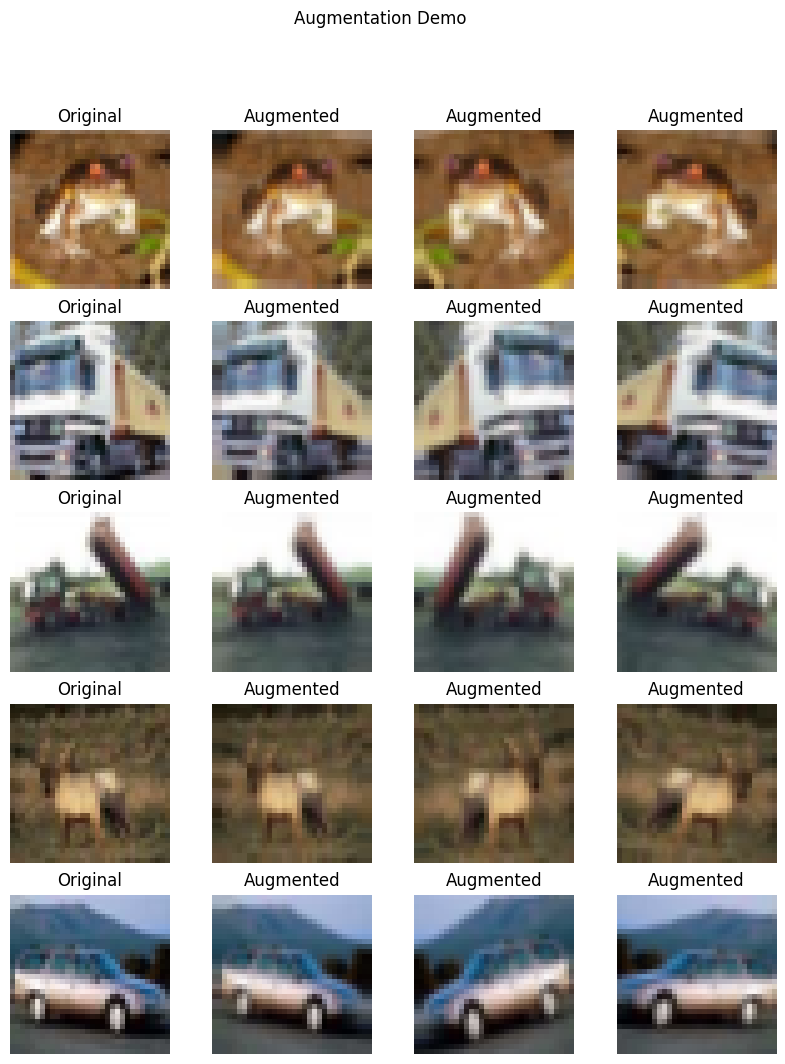

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

# Take 5 images
sample_images = x_train_cifar[:5]

fig, axes = plt.subplots(5, 4, figsize=(10,12))

for i in range(5):
    axes[i,0].imshow(sample_images[i])
    axes[i,0].set_title("Original")
    axes[i,0].axis('off')

    img = sample_images[i].reshape((1,) + sample_images[i].shape)

    aug_iter = datagen.flow(img, batch_size=1, seed=42)

    for j in range(1,4):
        aug_img = next(aug_iter)[0].astype('uint8')
        axes[i,j].imshow(aug_img)
        axes[i,j].set_title("Augmented")
        axes[i,j].axis('off')

plt.suptitle("Augmentation Demo")
plt.savefig("augmentation_demo.png")
plt.show()

The channel dimension (C) represents the number of color channels in an image.

For a grayscale image, C = 1 because there is only intensity information.
For an RGB image, C = 3 representing Red, Green, and Blue channels.

Thus, (N, H, W, C) means N images, each with height H, width W, and C channels.

For large images like 1024×1024, the following strategies can be used:

1. Data Generators / Lazy Loading:
   Load images in batches instead of loading the entire dataset into memory.

2. Image Resizing / Downsampling:
   Reduce image resolution to a manageable size before training.

3. Patch-based Training:
   Divide large images into smaller patches and train on patches.

These techniques reduce memory usage and allow training on limited hardware.

This approach is incorrect because it introduces data leakage.

The test set should remain completely unseen during training and preprocessing.
Using statistics from the test set makes the model indirectly learn from it,
leading to overly optimistic performance.

Instead, normalization parameters must be computed only from the training set
and applied to validation and test sets.